In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("ToyotaCorolla - MLR.csv")

In [3]:
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

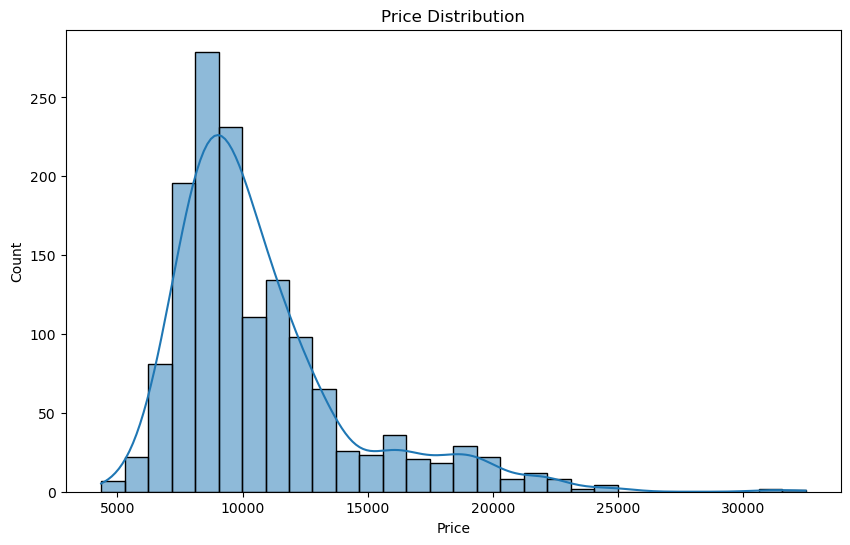

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.show()

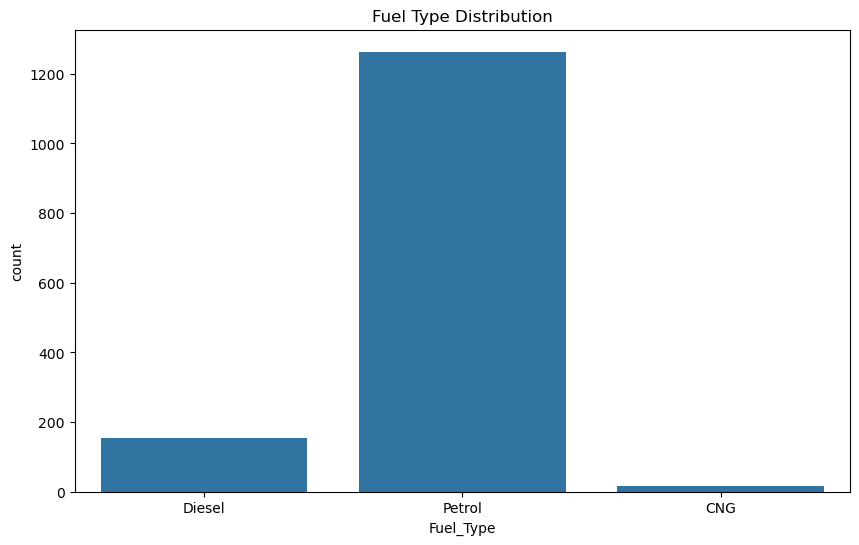

In [6]:
plt.figure(figsize=(10,6))
sns.countplot(x='Fuel_Type', data=df)
plt.title('Fuel Type Distribution')
plt.show()

In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

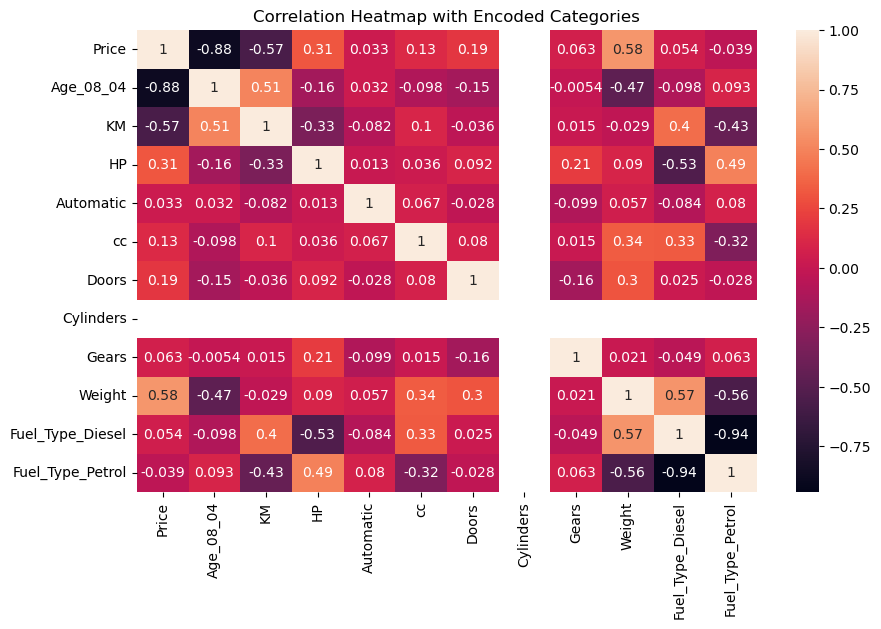

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True)
plt.title('Correlation Heatmap with Encoded Categories')
plt.show()

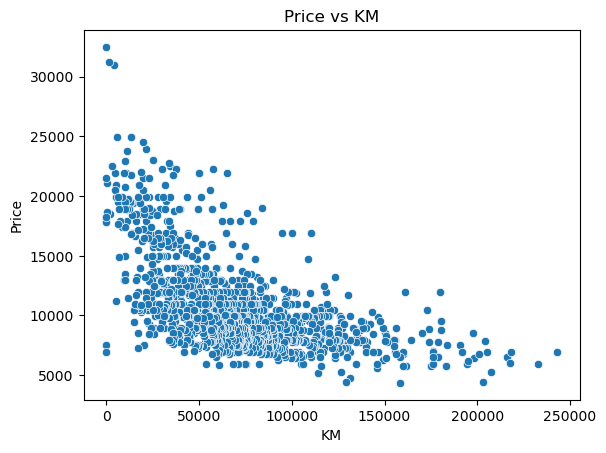

In [9]:
sns.scatterplot(x=df['KM'], y=df['Price'])
plt.title('Price vs KM')
plt.show()

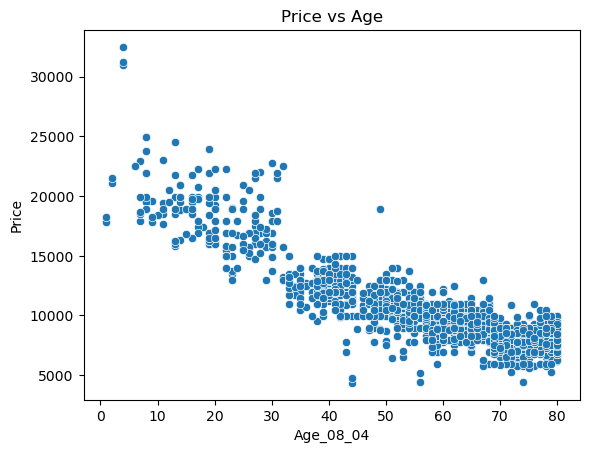

In [10]:
sns.scatterplot(x=df['Age_08_04'], y=df['Price'])
plt.title('Price vs Age')
plt.show()

In [11]:
target=df["Price"]
feature=df.drop(columns=["Price"])

In [12]:
target

0       13500
1       13750
2       13950
3       14950
4       13750
        ...  
1431     7500
1432    10845
1433     8500
1434     7250
1435     6950
Name: Price, Length: 1436, dtype: int64

In [13]:
feature

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,23,46986,Diesel,90,0,2000,3,4,5,1165
1,23,72937,Diesel,90,0,2000,3,4,5,1165
2,24,41711,Diesel,90,0,2000,3,4,5,1165
3,26,48000,Diesel,90,0,2000,3,4,5,1165
4,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...
1431,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,70,16916,Petrol,86,0,1300,3,4,5,1015


In [14]:
ohe = OneHotEncoder(drop='first', sparse_output=False)
feature_ohe = ohe.fit_transform(feature[['Fuel_Type', 'Automatic']])
ohe_c = ohe.get_feature_names_out(['Fuel_Type', 'Automatic'])
feature= feature.drop(['Fuel_Type', 'Automatic'], axis=1)
feature = pd.concat([feature, pd.DataFrame(feature_ohe, columns=ohe_c, index=feature.index)], axis=1)

In [15]:
feature

,Age_08_04,KM,HP,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol,Automatic_1
0,23,46986,90,2000,3,4,5,1165,1.0,0.0,0.0
1,23,72937,90,2000,3,4,5,1165,1.0,0.0,0.0
2,24,41711,90,2000,3,4,5,1165,1.0,0.0,0.0
3,26,48000,90,2000,3,4,5,1165,1.0,0.0,0.0
4,30,38500,90,2000,3,4,5,1170,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1431,69,20544,86,1300,3,4,5,1025,0.0,1.0,0.0
1432,72,19000,86,1300,3,4,5,1015,0.0,1.0,0.0
1433,71,17016,86,1300,3,4,5,1015,0.0,1.0,0.0
1434,70,16916,86,1300,3,4,5,1015,0.0,1.0,0.0


In [16]:
x_train,x_test,y_train,y_test=train_test_split(feature,target,test_size=0.2,random_state=44)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(1148, 11)
(1148,)
(288, 11)
(288,)


In [17]:
sl=StandardScaler()

In [18]:
num_cols = ['Age_08_04', 'KM', 'HP', 'cc','Doors','Cylinders','Gears','Weight']
x_train[num_cols] = sl.fit_transform(x_train[num_cols])
x_test[num_cols] = sl.transform(x_test[num_cols])

In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = x_train.columns
vif_data['VIF'] = [variance_inflation_factor(x_train.values, i) 
                   for i in range(x_train.shape[1])]

print("\nVariance Inflation Factors")
print(vif_data.sort_values(by='VIF', ascending=False))



Variance Inflation Factors
             Feature       VIF
8   Fuel_Type_Diesel  4.219254
7             Weight  3.745694
2                 HP  2.401002
0          Age_08_04  1.976556
1                 KM  1.969934
9   Fuel_Type_Petrol  1.573115
4              Doors  1.226983
3                 cc  1.190055
10       Automatic_1  1.185296
6              Gears  1.101346
5          Cylinders       NaN


## multiple linear regression

In [20]:
lr=LinearRegression()

In [21]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
y_pred=lr.predict(x_test)

In [23]:
print('Linear Regression R2:', r2_score(y_test, y_pred))
print('Linear Regression MSE:', mean_squared_error(y_test, y_pred))
print('Coefficients:', lr.coef_)


Linear Regression R2: 0.8495776999301377
Linear Regression MSE: 2026556.8914604948
Coefficients: [-2.24385997e+03 -6.22222711e+02  2.12812810e+02 -9.75377976e+00
 -4.40659124e+01  2.47268872e-12  1.01193922e+02  1.27212617e+03
  2.75796633e+02  1.65699421e+03  1.38612108e+02]


##  Ridge Regression

In [24]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train, y_train)
y_pred_ridge = ridge.predict(x_test)
print('Ridge R2:', r2_score(y_test, y_pred_ridge))
print('Ridge MSE:', mean_squared_error(y_test, y_pred_ridge))
print('Ridge Coefficients:', ridge.coef_)

Ridge R2: 0.8501130655419362
Ridge MSE: 2019344.2051132082
Ridge Coefficients: [-2240.08186077  -628.14834217   212.90889084    -9.29397308
   -42.3655484      0.           102.61377761  1268.14530711
   157.85574588  1522.64948418   137.63127301]


## Lasso Regression

In [25]:
lasso = Lasso(alpha=1.0)
lasso.fit(x_train, y_train)
y_pred_lasso = lasso.predict(x_test)
print('Lasso R2:', r2_score(y_test, y_pred_lasso))
print('Lasso MSE:', mean_squared_error(y_test, y_pred_lasso))
print('Lasso Coefficients:', lasso.coef_)

Lasso R2: 0.8495145315804375
Lasso MSE: 2027407.9238828649
Lasso Coefficients: [-2240.66930552  -625.03695902   203.51580289    -6.09413303
   -43.62550133     0.           101.91097139  1277.76532539
    70.59626755  1487.19971794   112.95281004]


## Interview questions

### 1) Normalization vs Standardization

Normalization means adjusting numeric values so they fall within a small range, usually between 0 and 1. This is often used when features have very different scales and you want everything treated fairly. Algorithms based on distance, such as K-Nearest Neighbor or K-Means, rely on this type of scaling.

Standardization means reshaping the data so it has a mean of 0 and a standard deviation of 1. This is useful when the data looks roughly bell-shaped and when models, such as linear regression or SVM, assume features have similar spreads. Standardizing makes training more stable and helps the model learn faster.

In both cases, the goal is to avoid one feature dominating another just because it uses larger numbers.

### 2) Handling Multicollinearity in Multiple Linear Regression

Multicollinearity happens when two or more predictors are strongly related to each other. This makes it hard for the model to figure out which variable truly matters, and it can lead to unstable coefficients.

Ways to deal with it:

 Remove one of the highly correlated features if it doesn’t provide unique value.
 Combine related features into a single metric or score when they basically reflect the same idea.
 Use Principal Component Analysis (PCA) to convert correlated variables into new independent ones.
 Apply Ridge regression or other regularization methods to stabilize the coefficient values.
 Check VIF (Variance Inflation Factor) to spot which variables are causing trouble and fix them accordingly.

